In [ ]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

import scipy.stats as ss
import pandas as pd

import tqdm as tqdm

In [ ]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as ss

# магия для того, чтобы графики рисовались в векторном формате
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

In [ ]:
# import aesara.tensor as at
az.style.use("arviz-darkgrid")
rng = np.random.default_rng(7)

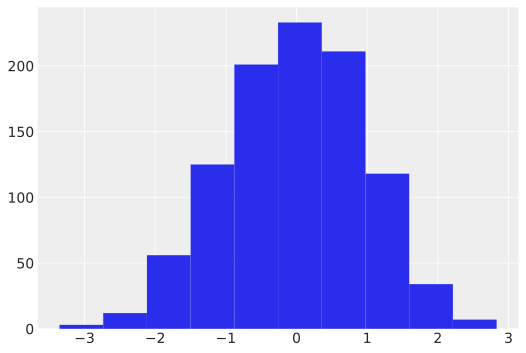

In [ ]:
data = ss.norm.rvs(size=1000, random_state=1337)
plt.hist(data)
data = data[(data > -1) & (data < 2)]

(array([ 87.,  96., 103., 117.,  99., 106.,  87.,  59.,  35.,  27.]),
 array([-0.98584963, -0.69488943, -0.40392924, -0.11296904,  0.17799116,
         0.46895135,  0.75991155,  1.05087175,  1.34183194,  1.63279214,
         1.92375234]),
 <BarContainer object of 10 artists>)

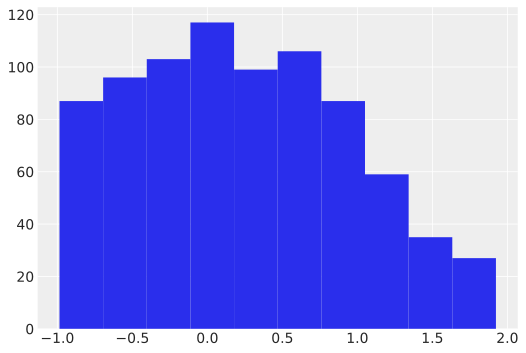

In [ ]:
plt.hist(data)

In [ ]:
import pymc as pm
import numpy as np

model = pm.Model()

with model:
    mu, sigma = pm.Flat("mu"), pm.HalfFlat("sigma")
    pm.Potential("p_mu_sigma", -pm.math.log(sigma))
    normal_dist = pm.Normal.dist(mu=mu, sigma=sigma)

    L, U = pm.Exponential("L", 1), pm.Exponential("U", 1)
    lower = pm.Deterministic("lower", data.min() - L)
    upper = pm.Deterministic("upper", data.max() + U)
    truncated = pm.Truncated("truncated_normal", normal_dist, lower=lower, upper=upper, observed=data)

with model:
    trace = pm.sample(draws=10000, chains=1, random_seed=rng)



Output()

In [ ]:
left, right = np.quantile(trace.posterior["sigma"].values.ravel(), [0.025, 0.975])
print(left, right)

0.9018928101525598 1.1852981220282817


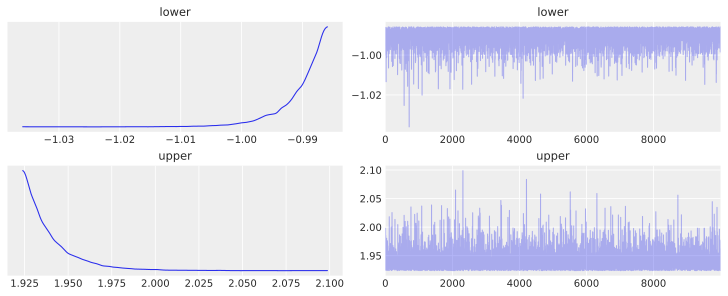

In [ ]:
az.plot_trace(trace, var_names=['lower', 'upper'], figsize = (10, 4), compact=False)
plt.show()

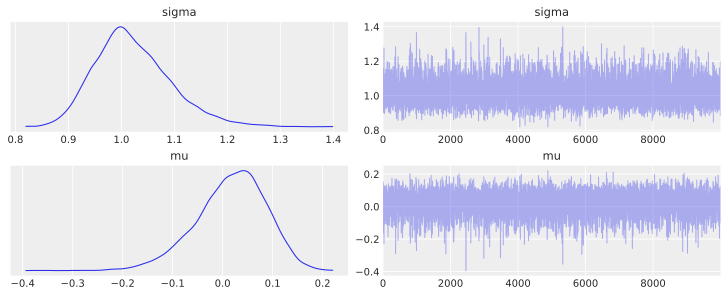

In [ ]:
az.plot_trace(trace, var_names=['sigma', 'mu'], figsize = (10, 4), compact=False)
plt.show()

In [ ]:
euro = pd.read_csv('https://stepik.org/media/attachments/lesson/1251114/euroweight.dat.txt', sep='\t', names=['weight', 'batch'], index_col=0)
print(euro.head())


   weight  batch
1   7.512      1
2   7.502      1
3   7.461      1
4   7.562      1
5   7.528      1


In [ ]:
euro.columns

Index(['weight', 'batch'], dtype='object')

In [ ]:
weight, batch = euro["weight"].to_numpy(), euro["batch"].to_numpy() - 1

euroweight = pm.Model()

with euroweight:
  mu_b = pm.Normal("mu_b", mu=0, sigma=100)
  sigma_b = pm.HalfNormal("sigma_b", sigma=5)
  mu_j = pm.Normal("mu_j", mu=mu_b, sigma=sigma_b, shape=8)

  mu_batch = mu_j
  sigma = pm.HalfNormal("sigma", sigma=10)

  weight_dist = pm.Normal("weight_obs",
                          mu=mu_j[batch],
                          sigma=sigma, observed=weight)


with euroweight:
  trace = pm.sample(draws=10000, chains=1, random_seed=rng)


Output()

In [ ]:
mu_samples = trace.posterior["mu_j"].values.reshape(-1, 8)
post_means = mu_samples.mean(axis=0)

i = np.argmax(post_means)
j = np.argmin(post_means)

diff_samples = mu_samples[:, i] - mu_samples[:, j]
left, right = np.quantile(diff_samples, [0.025, 0.975])

print(i + 1, j + 1)
print(left, right)

5 3
0.01443338712624762 0.026330499254662548


In [ ]:
import pandas as pd

data = pd.read_csv('https://stepik.org/media/attachments/lesson/832665/Fish.csv')
data = data.drop(40, axis=0)
print(data.head())



  Species  Weight  Length1  Length2  Length3   Height   Width
0   Bream   242.0     23.2     25.4     30.0  11.5200  4.0200
1   Bream   290.0     24.0     26.3     31.2  12.4800  4.3056
2   Bream   340.0     23.9     26.5     31.1  12.3778  4.6961
3   Bream   363.0     26.3     29.0     33.5  12.7300  4.4555
4   Bream   430.0     26.5     29.0     34.0  12.4440  5.1340


In [ ]:
1data.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

In [ ]:
Length = data["Length1"].to_numpy()
Height = data["Height"].to_numpy()
Width = data["Width"].to_numpy()
log_weight = np.log(data["Weight"].to_numpy())


fish_model = pm.Model()

with fish_model:
  beta = pm.Normal("beta", mu=0, sigma=100, shape=4)
  sigma = pm.HalfNormal('sigma', sigma=100)
  mu = ( beta[0]
        + beta[1] * np.log(Length)
        + beta[2] * np.log(Height)
        + beta[3] * np.log(Width))
  log_weight_obs = pm.Normal('log_weight_obs', mu=mu, sigma=sigma, observed=log_weight)


with fish_model:
  trace = pm.sample(draws=10000, chains=1, random_seed=rng)

Output()

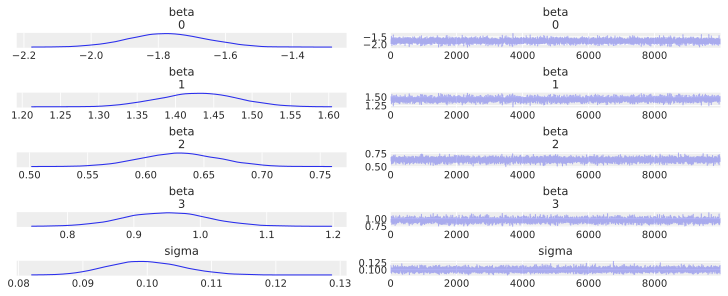

In [ ]:
az.plot_trace(trace, figsize = (10, 4), compact=False)
plt.show()

In [ ]:
trace.posterior["beta"].shape

(1, 10000, 4)

In [ ]:
beta_samples = trace.posterior["beta"].values.reshape(-1, 4)
sum = beta_samples[:, 1] + beta_samples[:, 2] + beta_samples[:, 3]
left, right = np.quantile(sum, [0.025, 0.975])
print(left, right)

2.9691057262185847 3.0458901839765202


In [ ]:
import numpy as np
import scipy.stats as ss

def average_risk(p1, p2, mu1, cov1, mu2, cov2):
    n = 10000

    dist1 = ss.multivariate_normal(mean=mu1, cov=cov1)
    dist2 = ss.multivariate_normal(mean=mu2, cov=cov2)

    errors = 0

    for _ in range(n):
        # 1) генерируем истинный класс
        y = 1 if np.random.rand() < p1 else 2

        # 2) генерируем объект из соответствующего распределения
        if y == 1:
            x = dist1.rvs()
        else:
            x = dist2.rvs()

        # 3) байесовское правило
        score1 = np.log(p1) + dist1.logpdf(x)
        score2 = np.log(p2) + dist2.logpdf(x)

        y_pred = 1 if score1 > score2 else 2

        # 4) считаем ошибку
        if y_pred != y:
            errors += 1

    return errors / n

In [ ]:
import numpy as np
import scipy.stats as ss

def average_risk(p1, p2, mu1, cov1, mu2, cov2):
    n = 10000
    rng = np.random.default_rng(0)

    dist1 = ss.multivariate_normal(mean=mu1, cov=cov1)
    dist2 = ss.multivariate_normal(mean=mu2, cov=cov2)

    # истинные классы
    y = np.where(rng.random(n) < p1, 1, 2)

    # генерируем объекты
    x = np.empty((n, 2))
    mask1 = (y == 1)
    mask2 = (y == 2)

    x[mask1] = dist1.rvs(size=mask1.sum(), random_state=rng)
    x[mask2] = dist2.rvs(size=mask2.sum(), random_state=rng)

    # байесовский классификатор
    score1 = np.log(p1) + dist1.logpdf(x)
    score2 = np.log(p2) + dist2.logpdf(x)

    y_pred = np.where(score1 > score2, 1, 2)

    return np.mean(y_pred != y)

In [ ]:
import numpy as np
import scipy.stats as ss


def average_risk(p1, p2, mu1, cov1, mu2, cov2):
    n = 10000
    rng = np.random.default_rng(42)

    dist1 = ss.multivariate_normal(mean=mu1, cov=cov1)
    dist2 = ss.multivariate_normal(mean=mu2, cov=cov2)

    y = rng.choice([1, 2], size=n, p=[p1, p2])
    x1 = dist1.rvs(size=n, random_state=rng)
    x2 = dist2.rvs(size=n, random_state=rng)
    x = np.where((y == 1)[:, None], x1, x2)

    score1 = np.log(p1) + dist1.logpdf(x)
    score2 = np.log(p2) + dist2.logpdf(x)

    y_pred = np.where(score1 > score2, 1, 2)
    error = np.mean(y_pred != y)

    return error

In [ ]:
average_risk(0.3, 0.7, [0, 0], [[1, 0.5], [0.5, 1]], [2.5, 0], [[1, -0.5], [-0.5, 1]])

np.float64(0.0859)

In [ ]:
import numpy as np
from scipy.stats import t

n_c, xbar_c, s_c = 32, 1.013, 0.24
n_t, xbar_t, s_t = 36, 1.173, 0.20

rng = np.random.default_rng(42)
N = 200000

mu_c = xbar_c + (s_c / np.sqrt(n_c)) * t.rvs(df=n_c - 1, size=N, random_state=rng)
mu_t = xbar_t + (s_t / np.sqrt(n_t)) * t.rvs(df=n_t - 1, size=N, random_state=rng)

delta = mu_t - mu_c
left, right = np.quantile(delta, [0.025, 0.975])

print(left, right)

0.05097153659334446 0.2700889209570675
